In [1]:

from ddsp import DDSP, AudioFeatureDataset
from ddsp.callbacks import BetaWarmupEpochCallback
from ddsp.synths import NoiseBandSynth, SineSynth, BendableNoiseBandSynth
from ddsp.utils import find_checkpoint

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer

from IPython.display import Audio, display

from torch.utils.data import DataLoader, Subset, random_split
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import umap

torch.set_float32_matmul_precision('medium')
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.set_default_device('cuda')

import os

experiment_root = '/home/btadeusz/code/ddsp_vae/experiments/feature_control'
models_root = os.path.join(experiment_root, 'models')
training_root = os.path.join(experiment_root, 'training')

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [2]:
# Dataset parameters
chunk_duration = 2.0
sampling_rate = 22050
n_signal = chunk_duration * sampling_rate
batch_size = 8
n_features = 2

# Model parameters
latent_size = num_params = 2
smoothing_kernel = 513
max_freq = sampling_rate//2
n_filters = 512
# n_sines = 100

# Training parameters
warmup_start = 50
warmup_end = 100
beta = 0.1
max_epochs = 1000
learning_rate = 1e-3
capacity = 8
gru_layers = 2

In [6]:
def get_dataset_split(dataset_path, validation_split=0.2):
  """
  Splits the dataset into training and validation sets.
  """
  generator=torch.Generator(device='cuda')

  dataset_A = AudioFeatureDataset(dataset_path=dataset_path, n_signal=n_signal, sampling_rate=sampling_rate)
  total_len = len(dataset_A)

  val_len = int(validation_split * total_len)  # 20% for validation
  indices = torch.randperm(total_len, generator=generator)

  val_indices = indices[:val_len]
  train_indices = indices[val_len:]

  train_set = Subset(dataset_A, train_indices)
  val_set = Subset(dataset_A, val_indices)

  train_loader = DataLoader(train_set, batch_size, shuffle=True, num_workers=0, generator=generator)
  val_loader = DataLoader(val_set, batch_size, shuffle=False, num_workers=0, generator=generator)

  return train_loader, val_loader


def build_ddsp_model():
  """
  Builds the DDSP model with the specified configurations.
  """
  # nbn = NoiseBandSynth.to_config(
  #   n_filters=n_filters,
  #   fs=sampling_rate,
  # )

  bnbn = BendableNoiseBandSynth.to_config(
    n_filters=n_filters,
    fs=sampling_rate,
  )

  # sines = SineSynth.to_config(
  #   n_sines=n_sines,
  #   fs=sampling_rate,
  # )

  ddsp = DDSP(
    # synth_configs=[nbn, sines],
    synth_configs=[bnbn],
    fs=sampling_rate,
    latent_size=latent_size,
    latent_smoothing_kernel=smoothing_kernel,
    decoder_gru_layers=gru_layers,
    num_params=num_params,
    n_features=n_features,
    learning_rate=learning_rate,
    perceptual_loss_weight=0,
    plateau_patience=20,
    capacity=capacity,
  ).to('cuda')

  return ddsp


def build_trainer(model_training_path):
  training_callbacks = []
  beta_warmup = BetaWarmupEpochCallback(
    beta=beta,
    start_epoch=warmup_start,
    end_epoch=warmup_end
  )
  training_callbacks.append(beta_warmup)

  best_checkpoint_callback = ModelCheckpoint(
    filename='best',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    save_last=True,
    dirpath=model_training_path
  )
  training_callbacks.append(best_checkpoint_callback)

  trainer = Trainer(
    callbacks=training_callbacks,
    max_epochs=max_epochs,
    accelerator='cuda',
    # precision=16,
  )

  return trainer


def train_on_dataset(dataset_path, model_name=None):
  """
  Trains the DDSP model on a specific dataset.
  """
  train_loader, val_loader = get_dataset_split(dataset_path)

  model = build_ddsp_model()

  model_training_path = os.path.join(training_root, model_name)
  trainer = build_trainer(model_training_path)

  ckpt = find_checkpoint(model_training_path, return_none=True, typ='last')
  print("Found ckpt: ", ckpt)
  trainer.fit(model, train_loader, val_loader, ckpt_path=ckpt)

  return model, trainer, train_loader, val_loader, model_training_path


def examine_model(model, val_loader, waveshaping=0.0):
  """
  Examines the trained model by displaying original and autoencoded audio samples,
  as well as reporting on the loss.
  """
  model = model.cuda()
  model.eval()
  with torch.no_grad():
    x_audio, x_features = next(iter(val_loader))
    x_audio = x_audio.to('cuda')

    # Forward pass through the model
    # y_audio = model(x_audio, x_features).squeeze(1)
    mu, scale = model.encoder(x_audio)
    z, _ = model.encoder.reparametrize(mu, scale)
    z = model._smooth_latents(z)
    # z = torch.zeros_like(z)
    x_features = torch.nn.functional.interpolate(x_features.permute(0, 2, 1), scale_factor=1/model.resampling_factor, mode='linear').permute(0, 2, 1)
    synth_params = model.decoder(x_features, z).squeeze(1)
    y_audio = model._synthesize(synth_params, waveshaping_factor=waveshaping)

    print(x_audio.shape, y_audio.shape)

    # Display original and reconstructed audio
    for j in range(x_audio.shape[0]):
      print(f"Sample {j + 1}:")
      x_audio_j = x_audio[j].cpu()
      y_audio_j = y_audio[j].cpu()

      import matplotlib.pyplot as plt
      import numpy as np

      # Convert to numpy for plotting
      waveform = x_audio_j.cpu().numpy()
      features = x_features[j].cpu().numpy()
      latents = z[j].cpu().numpy()

      # Time axis in seconds
      t = np.arange(waveform.shape[-1]) / sampling_rate

      # Feature names (assuming order: loudness, centroid, flatness, bandwidth)
      feature_names = ['loudness', 'centroid'] #, 'flatness', 'bandwidth']
      latent_names = [f'l{i+1}' for i in range(latents.shape[-1])]

      plt.figure(figsize=(14, 6))

      # Plot waveform
      sns.lineplot(x=t, y=waveform, label='waveform', color='gray', alpha=0.5)

      # Plot features (normalize for visualization)
      for i, name in enumerate(feature_names):
        f = features[:, i]
        f_norm = (f - f.min()) / (f.max() - f.min()) if f.max() > f.min() else f
        sns.lineplot(x=np.linspace(0, t[-1], len(f)), y=f_norm, label=name)

      # Plot latents (normalize for visualization)
      for i, name in enumerate(latent_names):
        l = latents[:, i] if latents.ndim == 2 else latents[i]
        l_norm = (l - l.min()) / (l.max() - l.min()) if l.max() > l.min() else l
        sns.lineplot(x=np.linspace(0, t[-1], len(l)), y=l_norm, label=name)

      # plt.xlim(0, 0.1)
      plt.xlabel('Time (s)')
      plt.title('Waveform, Features, and Latents')
      plt.legend()
      plt.tight_layout()
      plt.show()


      display(Audio(x_audio_j.numpy(), rate=sampling_rate))
      display(Audio(y_audio_j.numpy(), rate=sampling_rate))


In [20]:
model_name = f'klein-2feature-reactive-bendable'
model, trainer, train_loader, val_loader, training_path = train_on_dataset('/mnt/mariadata/datasets/noise-artists/klein/processed', model_name=model_name)

Creating new cache: /mnt/mariadata/datasets/noise-artists/klein/audio_cache_7dac8365.lmdb


Saving metadata: {'dataset_length': 1053, 'n_signal': 44100.0, 'sampling_rate': 22050, 'total_samps': 46441728, 'feat_dim': 2, 'chunk_samps': 10000000, 'dtype': 'float32'}


/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                    | Params | Mode 
------------------------------------------------------------------
0 | synths        | ModuleList              | 0      | train
1 | encoder       | VariationalEncoder      | 40.3 K | train
2 | decoder       | Decoder                 | 329 K  | train
3 | _mr_stft_loss | MultiResolutionSTFTLoss | 0      | train
------------------------------------------------------------------
369 K     Trainable params
0         Non-trainable params
369 K     Total params
1.478     Total estimated model 

Found ckpt:  None


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/lightning/pytorch/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


torch.Size([8, 44100]) torch.Size([8, 1, 44096])
Sample 1:


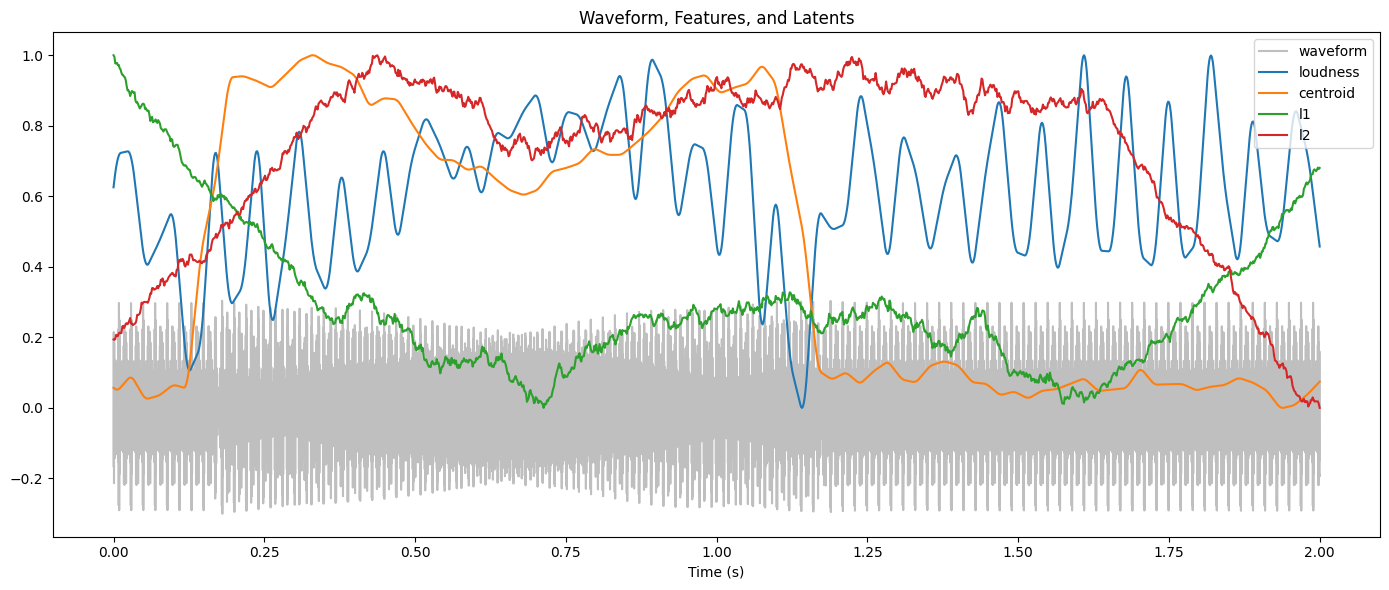

Sample 2:


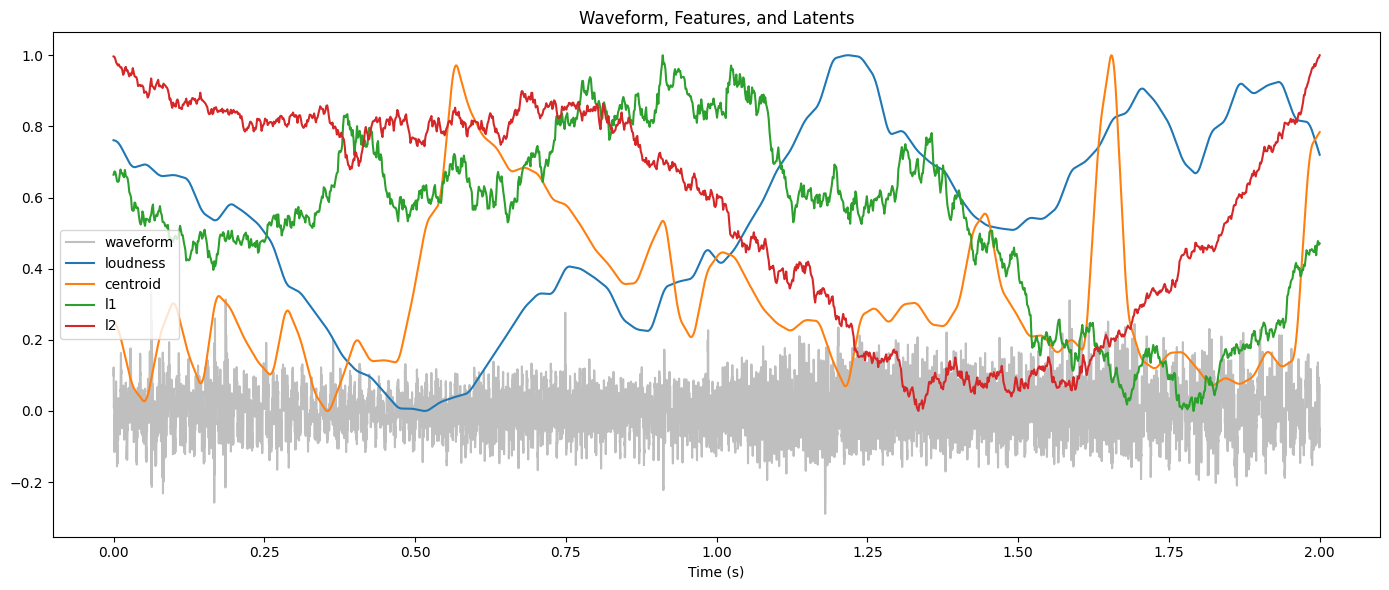

Sample 3:


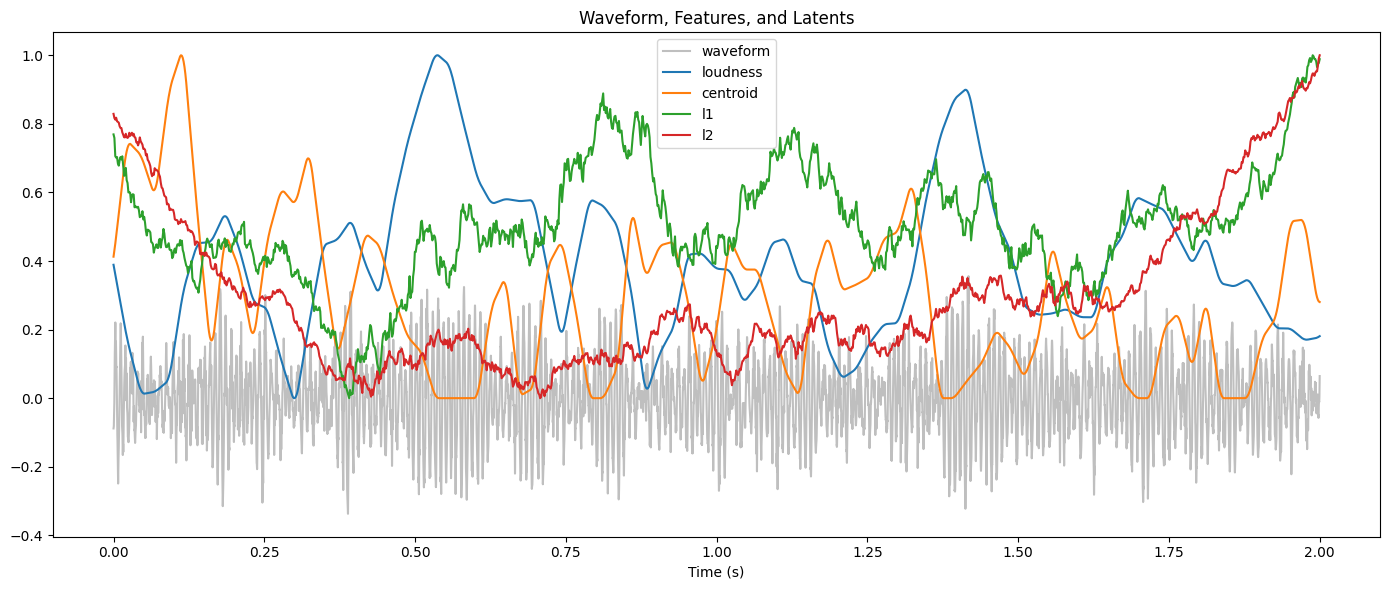

Sample 4:


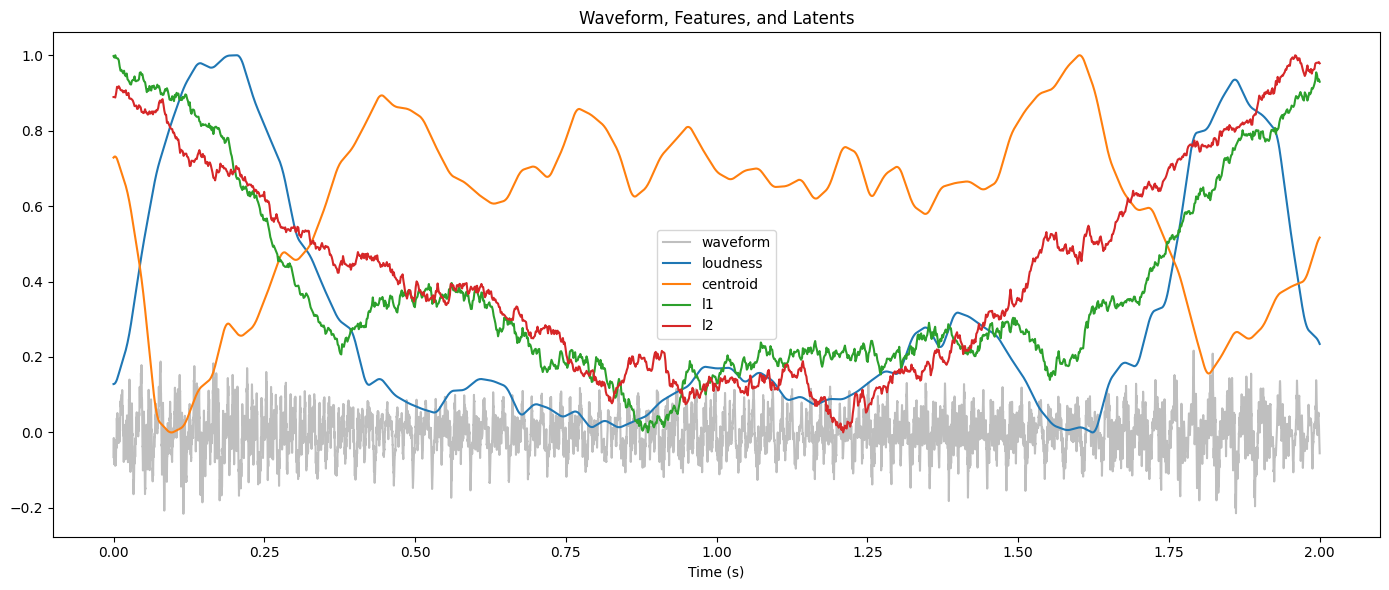

Sample 5:


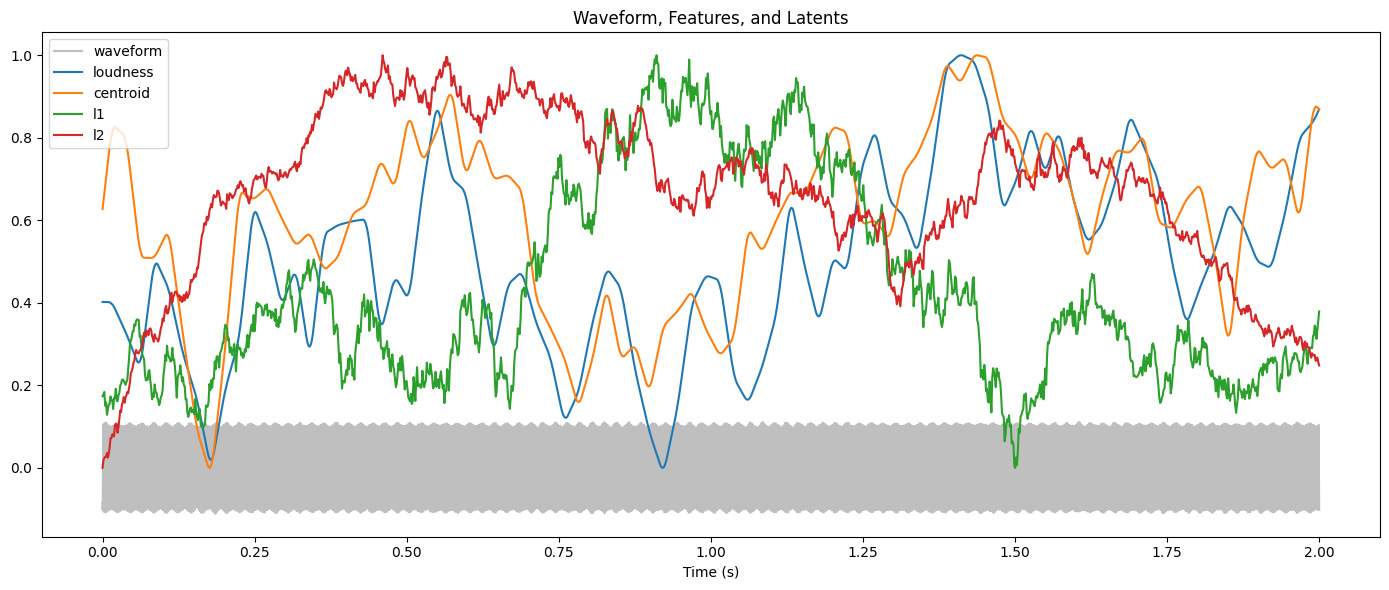

Sample 6:


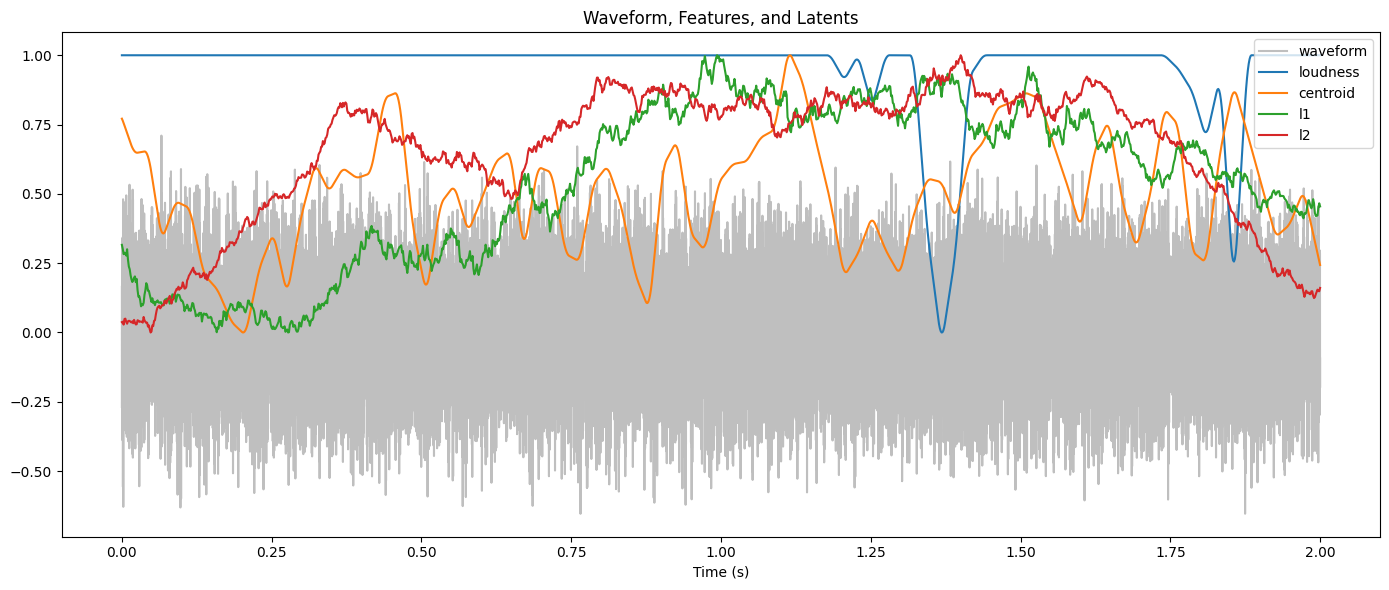

Sample 7:


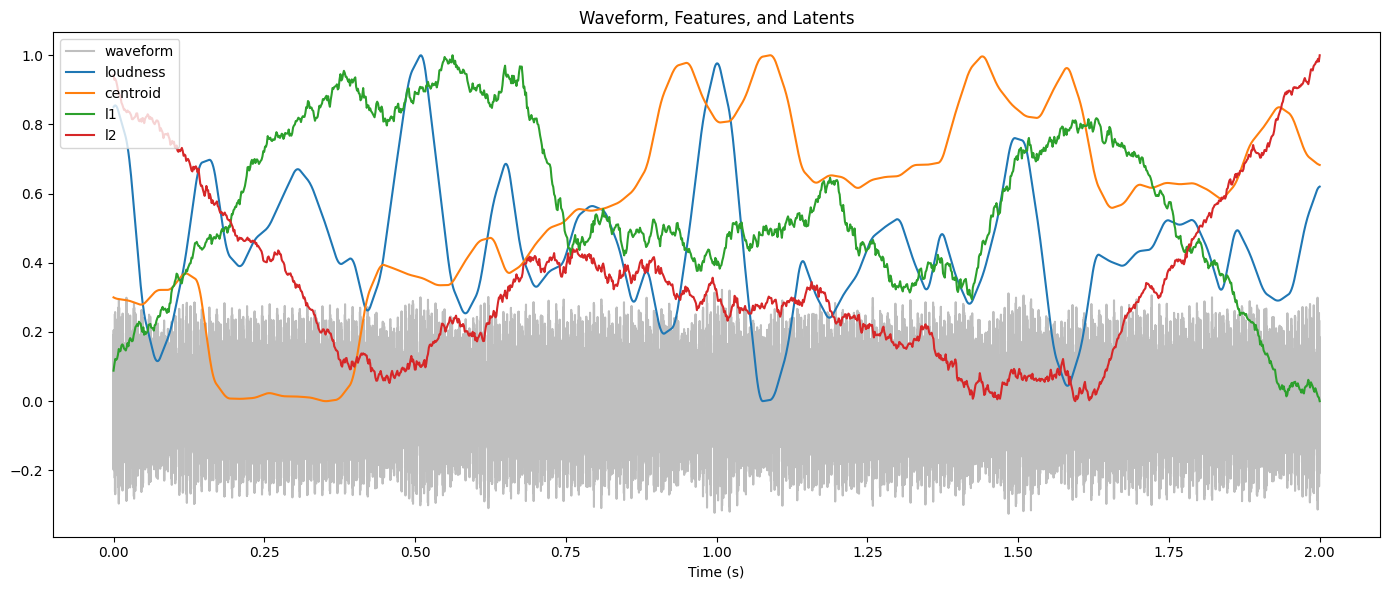

Sample 8:


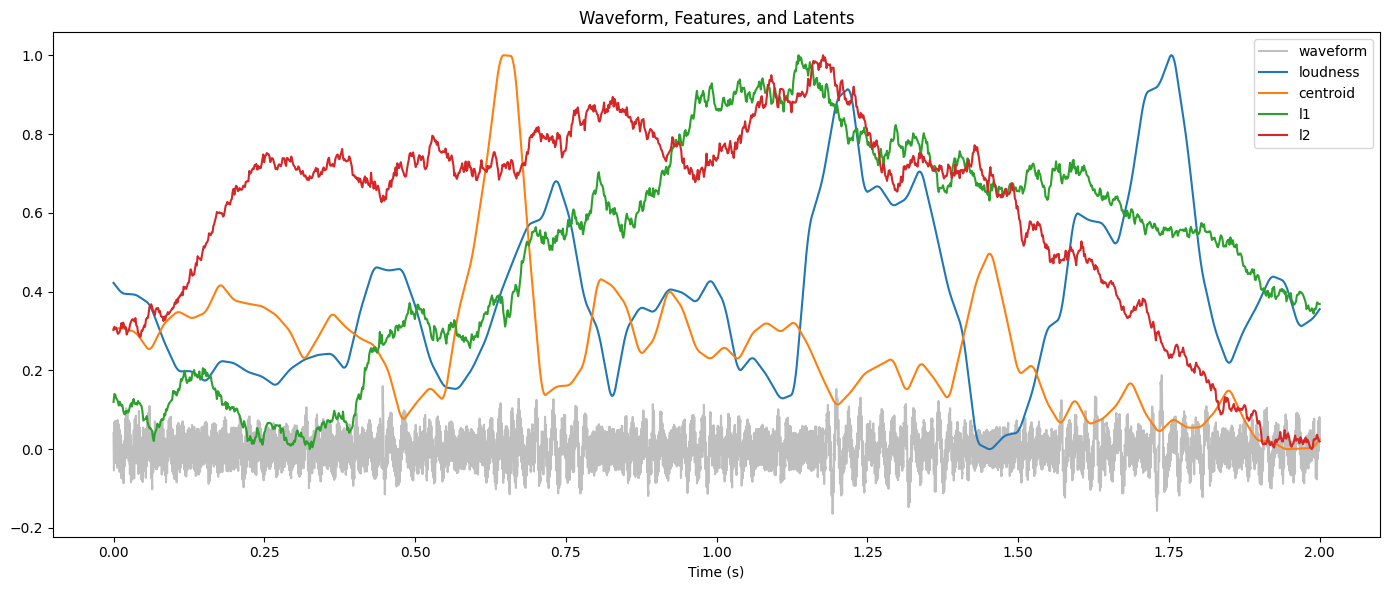

In [ ]:
examine_model(model, val_loader, waveshaping=0)

In [22]:
synth_output_path = os.path.join(models_root, f'{model_name}.ts')
!python -m cli.export --model_directory {training_path} --output_path {synth_output_path} --type last --target_fs 44100

exporting model from checkpoint: /home/btadeusz/code/ddsp_vae/experiments/feature_control/training/klein-2feature-reactive-bendable/last.ckpt
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
resample ratio: 2.0
Model exported to:  /home/btadeusz/code/ddsp_vae/experiments/feature_control/models/klein-2feature-reactive-bendable.ts
